# Canada Food CPI — CFPR Replica Experiment

This notebook reproduces the headline forecast from Canada's Food Price Report
(CFPR): a per-category estimate of the **average-year-over-average-year YoY
change** in Canada's food CPI indices for the year following a mid-year forecast
origin.  It evaluates baseline predictors across all nine canonical StatCan food
sub-indices and prepares the ground for later LLM and agent-based predictors.

**What you get in this notebook**

1. A quick visual tour of the nine food CPI sub-indices.
2. The canonical CFPR task loaded *from YAML* (so the spec is the source of
   truth) — backtest window 2009-2024, annual July origins, 12-step trajectory
   (horizons 6-17 = Jan-Dec of Y+1).
3. Two baseline predictors: `LastValuePredictor` (naive last-observed) and
   `DartsAutoARIMAPredictor`.
4. Backtest runs are **cached on disk** under `data/predictions/`; reruns are
   effectively free.
5. Leaderboards (CRPS, MAPE), trajectory fans, and the avg/avg YoY grid that
   mirrors what the CFPR publishes.
6. A budget-enforced protected eval (`data/eval_runs.yaml`) — left commented
   out so you don't spend a run by accident.

**What this notebook deliberately does not do**

- It does not use macro covariates (FRED).  That's a separate design question
  covered in `planning-docs/backlog.md` (see *covariate framing*).
- It does not introduce a new predictor.  Bring your own and swap it into the
  `predictors` list below.

---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.
- `reference_specs/food_cpi/food_cpi_cfpr_{backtest,eval}.yaml` are the specs.

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[2]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.evaluation.eval import EvalTracker
from methods.darts_arima import DartsAutoARIMAPredictor
from methods.naive import LastValuePredictor

from experiments.food_price_forecasting.analysis import (
    compute_avgyoy,
    compute_mape,
    predictions_to_dataframe,
    summarize_crps,
)
from experiments.food_price_forecasting.data import (
    CATEGORY_LABELS,
    build_food_cpi_service,
)
from experiments.food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_crps_disaggregated,
    plot_food_cpi_small_multiples,
    plot_mape_distribution,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
EVAL_RUNS_PATH = ROOT / "data" / "eval_runs.yaml"
SPECS_DIR = ROOT / "reference_specs" / "food_cpi"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

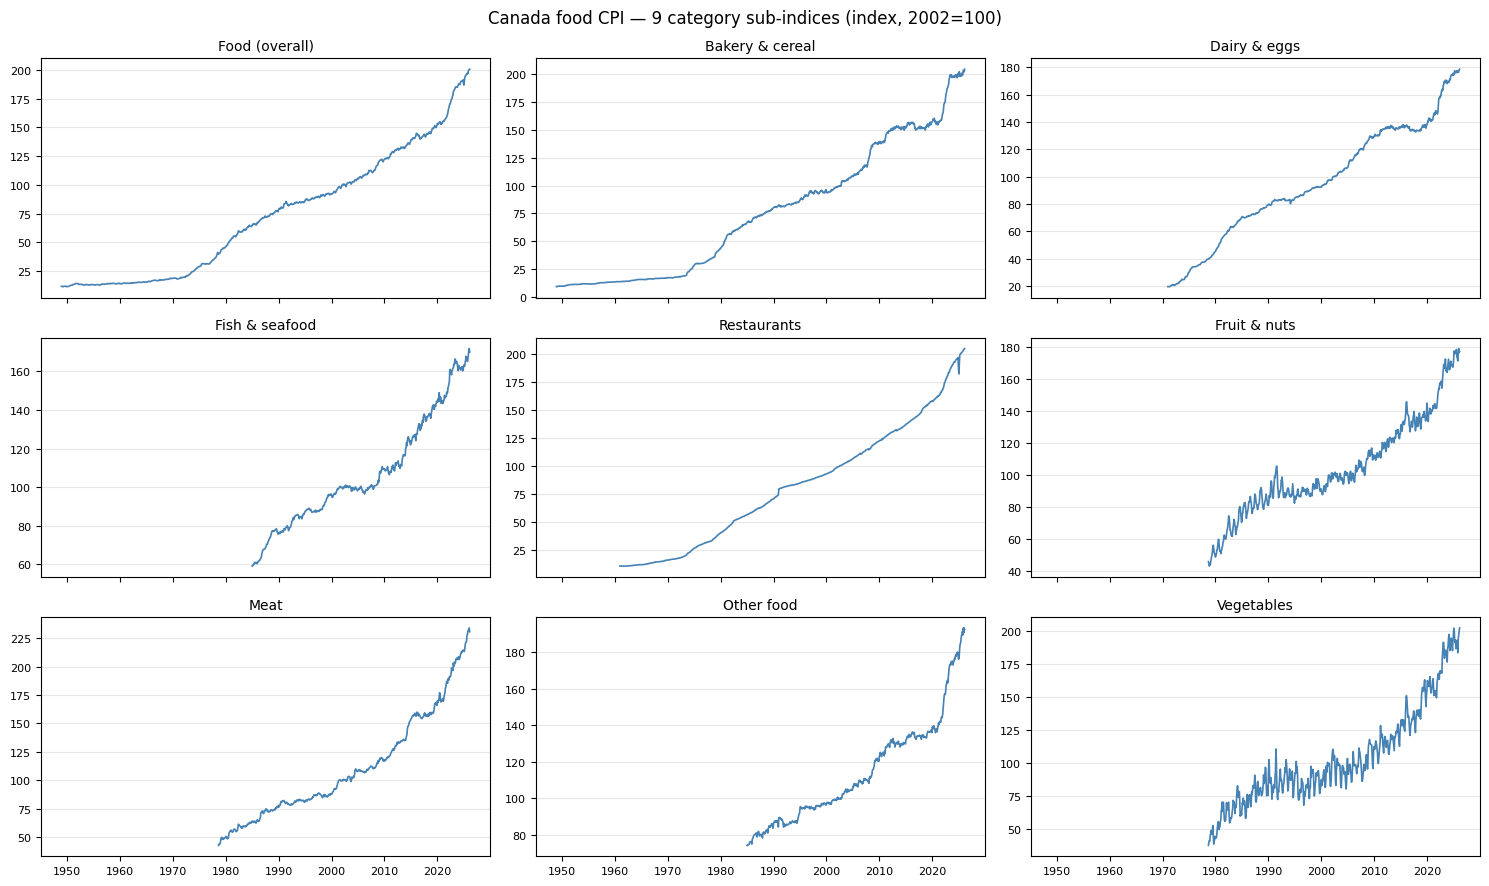

In [2]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The canonical CFPR task

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

In [3]:
with (SPECS_DIR / "food_cpi_cfpr_backtest.yaml").open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_cfpr_backtest)
  description: CFPR replica backtest: 9 Canadian food CPI sub-indices, annual July origins 2009-2024, 12-step trajectory (horizons 6-17) spanning Jan-Dec of the following calendar year.  Supports computation of the canonical average-over-average YoY CPI change that the Canada's Food Price Report publishes each year.  Open resource — run freely.
  start:       2009-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       9

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      M

---
## 4. Predictors

Two baselines — intentionally lean so the backtest runs in under a minute on a
laptop.  Both exercise the full multi-horizon trajectory API.  Extend
the `predictors` list with your own `Predictor` subclass when you're ready.

- `LastValuePredictor` — repeats the last observed value, fixed narrow spread.
- `DartsAutoARIMAPredictor` — auto-ARIMA per origin with probabilistic output.

In [4]:
predictors = [
    LastValuePredictor(),
    DartsAutoARIMAPredictor(),
]

PREDICTOR_COLORS: dict[str, str] = {
    "last_value_naive": "#7f7f7f",
    "darts_autoarima": "#1f77b4",
}

for p in predictors:
    print(f"  {p.predictor_id}")

  last_value_naive
  darts_autoarima


---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on the
next run.  Pass `force_refresh=True` to invalidate the cache for a predictor.

In [5]:
results_by_predictor: dict[str, dict[str, object]] = {}
for predictor in predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_crps:.4f}  ({len(result.predictions)} preds)")

Running last_value_naive ...


  food_cpi_overall_cfpr                       mean CRPS = 4.3958  (192 preds)
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.8276  (192 preds)
  food_cpi_dairy_eggs_cfpr                    mean CRPS = 3.5891  (192 preds)
  food_cpi_fish_seafood_cfpr                  mean CRPS = 3.6151  (192 preds)
  food_cpi_restaurants_cfpr                   mean CRPS = 5.2771  (192 preds)
  food_cpi_fruit_preparations_nuts_cfpr       mean CRPS = 4.6682  (192 preds)
  food_cpi_meat_cfpr                          mean CRPS = 6.8464  (192 preds)
  food_cpi_other_food_cfpr                    mean CRPS = 4.5427  (192 preds)
  food_cpi_vegetables_cfpr                    mean CRPS = 7.2313  (192 preds)
Running darts_autoarima ...


  food_cpi_overall_cfpr                       mean CRPS = 2.5167  (192 preds)
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.8179  (192 preds)
  food_cpi_dairy_eggs_cfpr                    mean CRPS = 2.5638  (192 preds)
  food_cpi_fish_seafood_cfpr                  mean CRPS = 2.2337  (192 preds)
  food_cpi_restaurants_cfpr                   mean CRPS = 1.6009  (192 preds)
  food_cpi_fruit_preparations_nuts_cfpr       mean CRPS = 3.3753  (192 preds)
  food_cpi_meat_cfpr                          mean CRPS = 3.4480  (192 preds)
  food_cpi_other_food_cfpr                    mean CRPS = 3.0045  (192 preds)
  food_cpi_vegetables_cfpr                    mean CRPS = 5.2520  (192 preds)


---
## 6. Trajectories — overall food CPI

For the overall Canadian food CPI, show the three most recent origins with each
predictor's 12-step trajectory fan.  Solid black is observed history, dashed
black is the Y+1 actuals where available, fans are the predictor's 90%/50%
intervals with the median in colour.

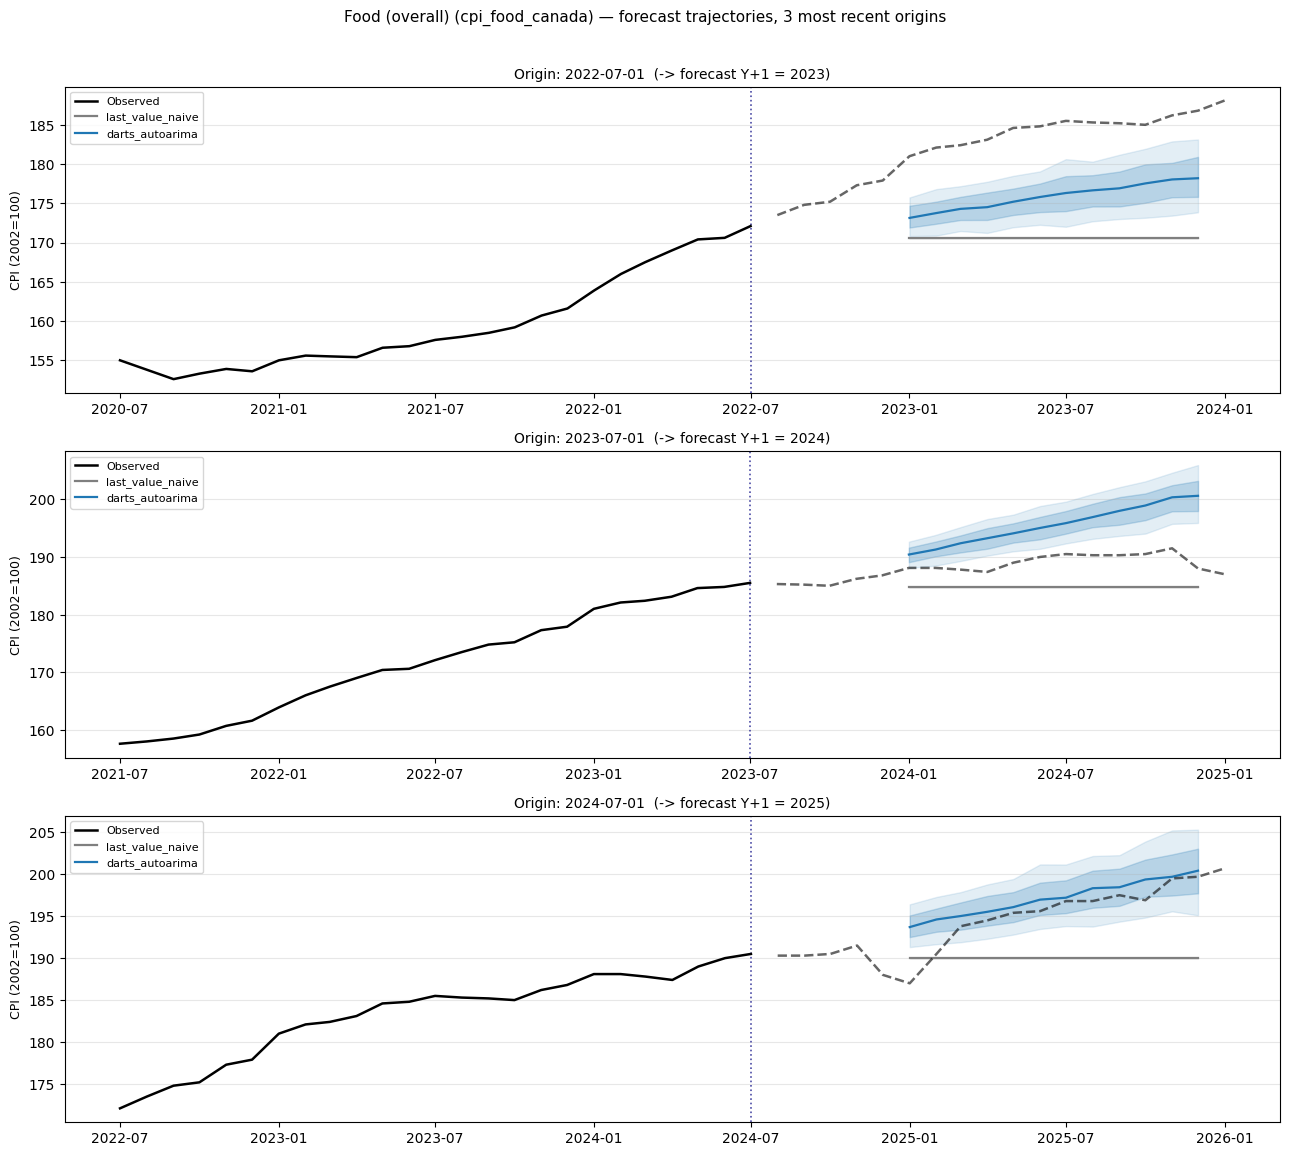

In [6]:
FOCAL_TASK = "food_cpi_overall_cfpr"
FOCAL_SERIES = "cpi_food_canada"

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 7. Avg/avg YoY — all 9 categories

The headline CFPR metric.  For each July origin, we compare the mean observed
CPI for year Y to the mean predicted CPI for year Y+1 across the 12 trajectory
horizons.  Actual realised YoY (solid black) is the out-of-sample truth for
every completed year.

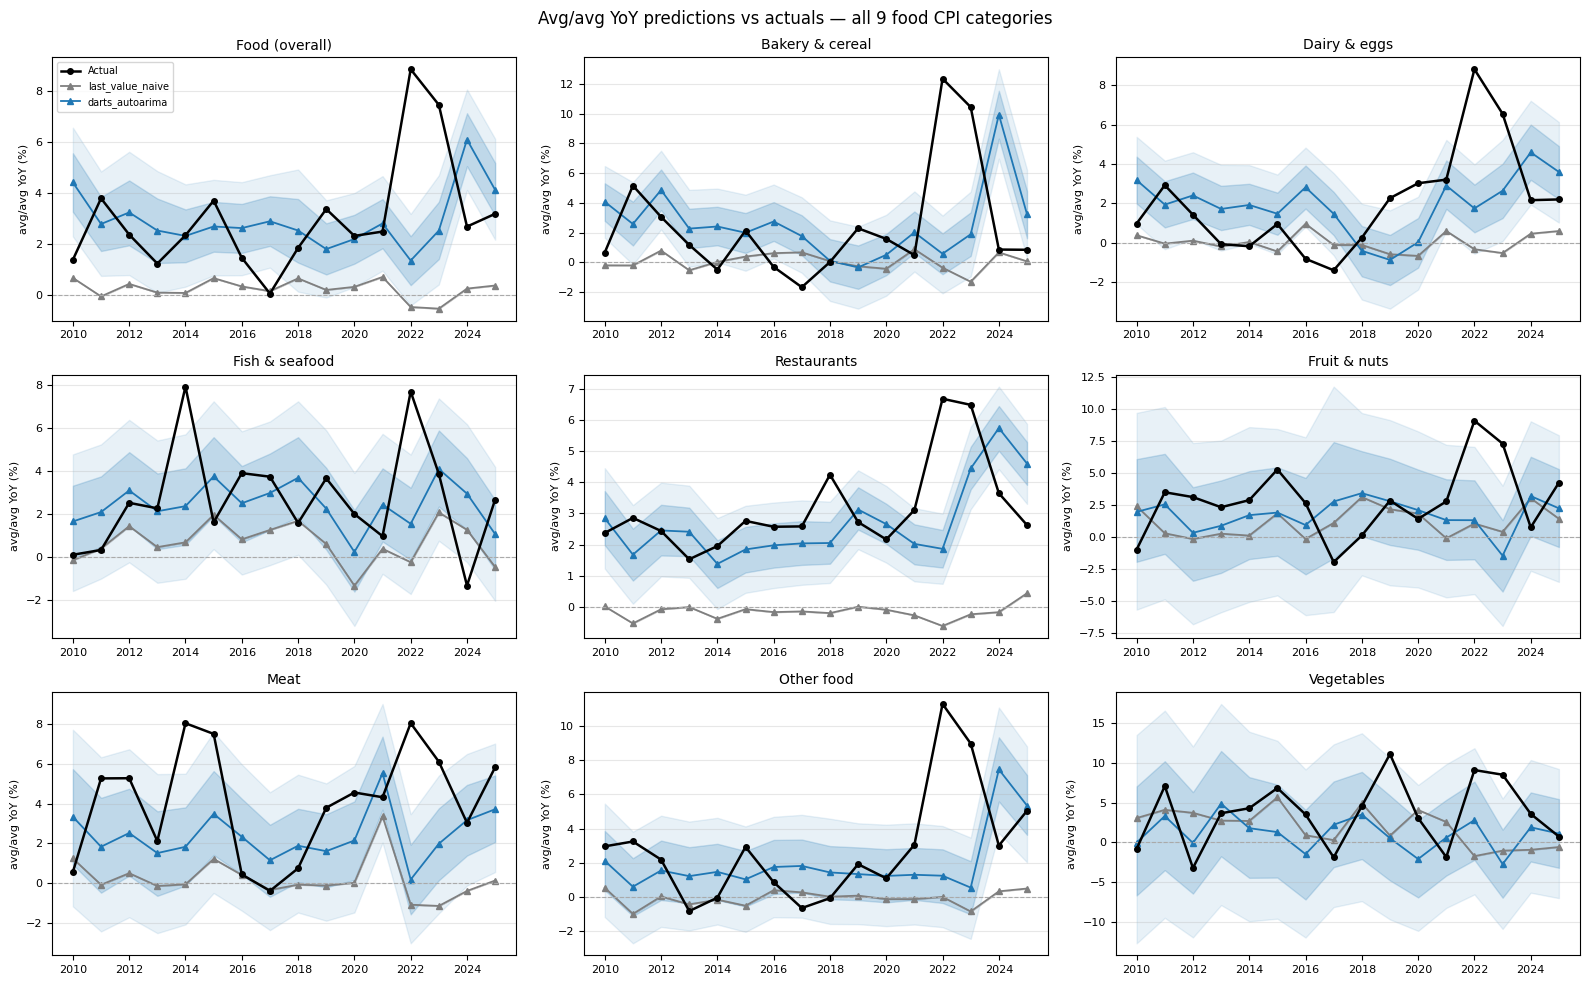

In [7]:
yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

from datetime import datetime, timezone

import pandas as pd


_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 8. Leaderboards

### 8.1 Mean CRPS per (predictor, task)

Lower is better.  The `MEAN` row is the across-category average.

In [8]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

predictor_id                           darts_autoarima  last_value_naive
task_id                                                                 
food_cpi_bakery_cereal_cfpr                   4.817900          4.827600
food_cpi_dairy_eggs_cfpr                      2.563800          3.589100
food_cpi_fish_seafood_cfpr                    2.233700          3.615100
food_cpi_fruit_preparations_nuts_cfpr         3.375300          4.668200
food_cpi_meat_cfpr                            3.448000          6.846400
food_cpi_other_food_cfpr                      3.004500          4.542700
food_cpi_overall_cfpr                         2.516700          4.395800
food_cpi_restaurants_cfpr                     1.600900          5.277100
food_cpi_vegetables_cfpr                      5.252000          7.231200
MEAN                                          3.201422          4.999244


### 8.2 CRPS disaggregated by origin year and horizon

Two quick diagnostics on the pooled prediction tape:

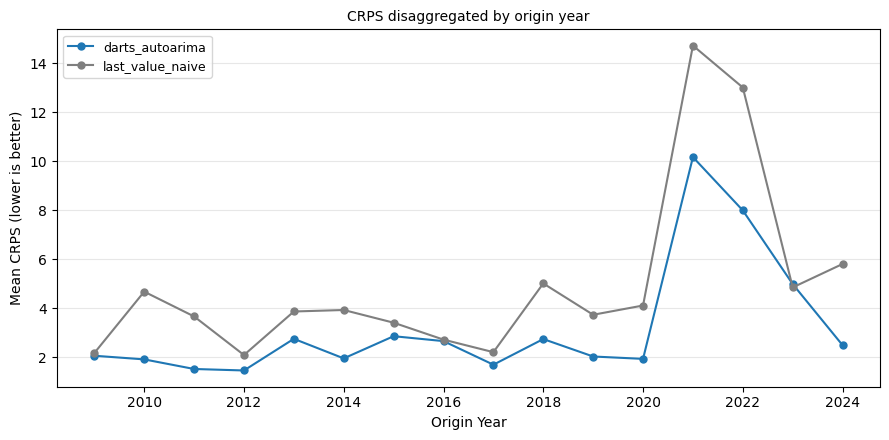

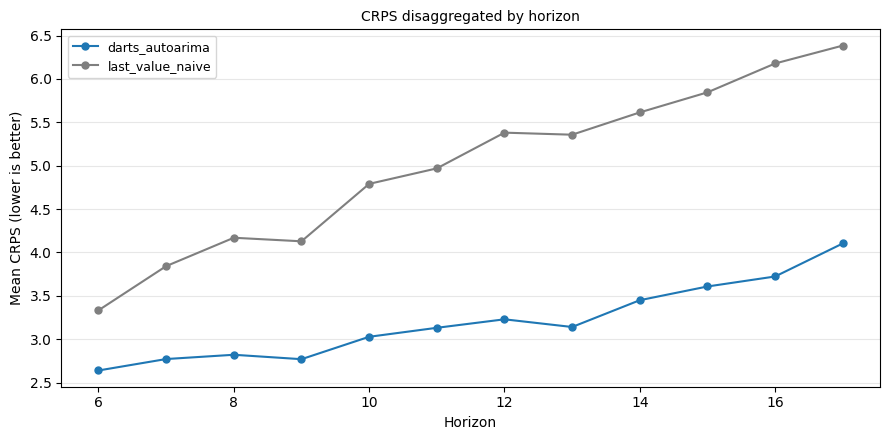

In [9]:
all_preds_df = pd.concat(
    [predictions_to_dataframe(task_results) for task_results in results_by_predictor.values()],
    ignore_index=True,
)

fig, _ = plot_crps_disaggregated(all_preds_df, by="origin_year", colors=PREDICTOR_COLORS)
plt.show()
fig, _ = plot_crps_disaggregated(all_preds_df, by="horizon", colors=PREDICTOR_COLORS)
plt.show()

### 8.3 MAPE per task — box-plot

MAPE is a single-point sanity check on the medians (CRPS is the full-distribution
score).

predictor_id                           darts_autoarima  last_value_naive
task_id                                                                 
food_cpi_bakery_cereal_cfpr                      3.415             2.827
food_cpi_dairy_eggs_cfpr                         2.294             2.368
food_cpi_fish_seafood_cfpr                       2.175             2.558
food_cpi_fruit_preparations_nuts_cfpr            3.194             3.298
food_cpi_meat_cfpr                               2.786             3.985
food_cpi_other_food_cfpr                         2.527             2.947
food_cpi_overall_cfpr                            1.966             2.732
food_cpi_restaurants_cfpr                        1.230             3.282
food_cpi_vegetables_cfpr                         4.804             4.870


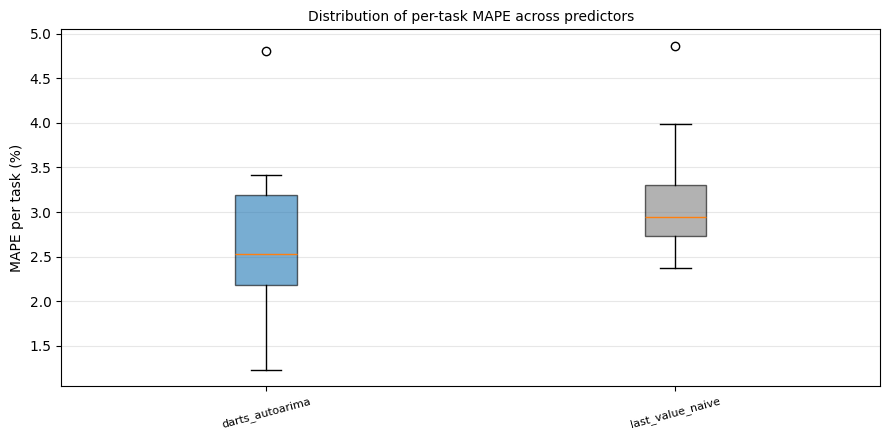

In [10]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

fig, _ = plot_mape_distribution(mape_df, colors=PREDICTOR_COLORS)
plt.show()

---
## 9. Latest-origin avg/avg YoY — headline table

What the CFPR would publish: the best predictor's avg/avg YoY central estimate
and uncertainty band for the forecast year, per category, from the most recent
July origin in the backtest window.

In [11]:
best_pid = crps_board.loc["MEAN"].idxmin()
print(f"Best predictor by cross-category mean CRPS: {best_pid}")

rows: list[dict[str, object]] = []
for task_id, yoy_df in yoy_by_predictor_by_task[best_pid].items():
    if yoy_df is None or yoy_df.empty:
        continue
    latest = yoy_df.sort_values("origin_year").iloc[-1]
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "origin_year": int(latest["origin_year"]),
            "forecast_year": int(latest["origin_year"]) + 1,
            "median_yoy_%": round(latest["yoy_median"] * 100, 2),
            "q05_%": round(latest["yoy_q05"] * 100, 2),
            "q25_%": round(latest["yoy_q25"] * 100, 2),
            "q75_%": round(latest["yoy_q75"] * 100, 2),
            "q95_%": round(latest["yoy_q95"] * 100, 2),
            "actual_yoy_%": None if pd.isna(latest["actual_yoy"]) else round(latest["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print(headline.to_string())

Best predictor by cross-category mean CRPS: darts_autoarima
                 origin_year  forecast_year  median_yoy_%  q05_%  q25_%  q75_%  q95_%  actual_yoy_%
category                                                                                           
Food (overall)          2024           2025          4.13   2.17   3.12   5.19   6.14          3.19
Bakery & cereal         2024           2025          3.23   0.29   1.62   4.79   6.22          0.84
Dairy & eggs            2024           2025          3.59   1.02   2.21   4.91   6.13          2.20
Fish & seafood          2024           2025          1.07  -2.04  -0.60   2.65   4.19          2.67
Restaurants             2024           2025          4.60   3.31   3.92   5.29   5.87          2.63
Fruit & nuts            2024           2025          2.24  -3.51  -0.78   5.30   7.94          4.24
Meat                    2024           2025          3.72   0.56   2.07   5.41   7.02          5.83
Other food              2024           2

---
## 10. Protected evaluation

`EvalTracker` enforces `max_runs` from the YAML spec against a shared
`data/eval_runs.yaml` file.  Run this only when you believe the predictor
is ready for a final assessment — each call spends one of your five runs.

In [12]:
with (SPECS_DIR / "food_cpi_cfpr_eval.yaml").open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

print(describe_spec(eval_spec, data_service=svc))

tracker = EvalTracker(EVAL_RUNS_PATH)
used = tracker.runs_for(eval_spec.spec_id)
print(f"\nBudget: {used} / {eval_spec.max_runs} runs used for spec '{eval_spec.spec_id}'.")

MultiTargetEvalSpec (spec_id=food_cpi_cfpr_eval)
  description: CFPR replica protected evaluation: 9 Canadian food CPI sub-indices, last 4 annual July origins 2021-2024, 12-step trajectory (horizons 6-17) spanning Jan-Dec of the following calendar year.  Budget: 5 multi_evaluate() calls per participant.
  start:       2021-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  max_runs:    5
  tasks:       9

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      MS

Task: food_cpi_bakery_cereal_cfpr
  description: Canada CPI Bakery and cereal p

In [13]:
# ── Uncomment to spend a run ──────────────────────────────────────────────────
# from aieng.forecasting.evaluation.eval import multi_evaluate
#
# best_predictor = next(p for p in predictors if p.predictor_id == best_pid)
# eval_results = multi_evaluate(
#     predictor=best_predictor,
#     spec=eval_spec,
#     data_service=svc,
#     tracker=tracker,
# )
# for task_id, r in eval_results.items():
#     print(f"  {task_id:42s}  mean CRPS = {r.mean_crps:.4f}  (run {r.run_number}/{eval_spec.max_runs})")